In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import glob, gc
%run ../commonvis.py

def roc_curve(d):
	nc = f'mncoef'
	fpr = []; tpr = []
	incr = (d.obs[nc].max()-d.obs[nc].min())/200
	for t in np.arange(d.obs[nc].min()-incr, d.obs[nc].max()+2*incr, incr):
		pos = d.obs.case > 0.1
		null = (d.obs.case <= 0.1)
		pred_pos = d.obs[nc] > t
		pred_null = d.obs[nc] <= t

		fpr.append((pred_pos & null).sum() / null.sum())
		tpr.append((pos & pred_pos).sum() / pos.sum())
	roc = pd.DataFrame({'fpr':fpr, 'tpr':tpr})
	roc = roc.dropna().sort_values(by='fpr')
	return np.trapezoid(roc.tpr, x=roc.fpr), roc

In [2]:
# read in relative abundance results
results = {}
for ratio in [1,1.2,1.4,1.6,1.8,2,2.4,2.8]:
    results[ratio] = []
    for f in glob.glob(f'_results/ratio{ratio:.2f}*_D.h5ad'):
        if 'caseonly' in f:
            continue
        print('.', end='')
        results[ratio].append(sc.read_h5ad(f))
    print(ratio, len(results[ratio]))

info = pd.DataFrame(columns=['ratio', 'power', 'power_std', 'auroc', 'auroc_std', 'n'])
for ratio in sorted(results.keys()):
    print(f'Processing ratio={ratio}')
    adatas = results[ratio]
    pvals = np.array([ad.uns['vima_p'] for ad in adatas])
    aurocs = np.array([roc_curve(ad)[0] for ad in adatas])
    
    row = pd.DataFrame([{
        'ratio': ratio,
        'power': (pvals < 0.05).mean(),
        'power_std': (pvals < 0.05).std(),
        'auroc': aurocs.mean(),
        'auroc_std': aurocs.std(),
        'n': float(len(adatas))
    }])
    info = pd.concat([info, row], ignore_index=True)

info.to_csv('relative_abundance_performance.csv', index=False)
del results; del adatas;
gc.collect()

..............................1 30
...............................1.2 31
..............................1.4 30
..............................1.6 30
..............................1.8 30
..............................2 30
...........................2.4 27
.............................2.8 29
Processing ratio=1


/tmp/ipykernel_4010600/2967875021.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, row], ignore_index=True)


Processing ratio=1.2
Processing ratio=1.4
Processing ratio=1.6
Processing ratio=1.8
Processing ratio=2
Processing ratio=2.4
Processing ratio=2.8


44

In [2]:
# read in relative abundance results
results_caseonly = {}
for ratio in [0, 0.01, 0.25, 0.38, 0.5, 0.75, 1]:
    results_caseonly[ratio] = []
    for f in glob.glob(f'_results/ratio{ratio:.2f}*_caseonly_D.h5ad'):
        print('.', end='')
        results_caseonly[ratio].append(sc.read_h5ad(f))
    print(ratio, len(results_caseonly[ratio]))

info = pd.DataFrame(columns=['ratio', 'power', 'power_std', 'auroc', 'auroc_std', 'case_mean', 'case_std', 'n'])
for ratio in sorted(results_caseonly.keys()):
    print(f'Processing ratio={ratio}')
    adatas = results_caseonly[ratio]
    pvals = np.array([ad.uns['vima_p'] for ad in adatas])
    aurocs = np.array([roc_curve(ad)[0] for ad in adatas])
    cases = np.array([ad.obs.groupby('sid').case.aggregate('mean').replace(0, np.nan).dropna().mean() for ad in adatas])
    
    row = pd.DataFrame([{
        'ratio': ratio,
        'power': (pvals < 0.05).mean(),
        'power_std': (pvals < 0.05).std(),
        'auroc': aurocs.mean(),
        'auroc_std': aurocs.std(),
        'case_mean': cases.mean(),
        'case_std': cases.std(),
        'n': float(len(adatas))
    }])
    info = pd.concat([info, row], ignore_index=True)

info.to_csv('caseonly_abundance_performance.csv', index=False)

..............................0 30
..............................0.01 30
..............................0.25 30
..............................0.38 30
..............................0.5 30
..............................0.75 30
..............................1 30
Processing ratio=0


/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.append((pos & pred_pos).sum() / pos.sum())
/tmp/ipykernel_2929511/1564556163.py:21: RuntimeWarning: invalid value encountered in scalar divide
  tpr.

Processing ratio=0.01


/tmp/ipykernel_2929511/499167296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cases = np.array([ad.obs.groupby('sid').case.aggregate('mean').replace(0, np.nan).dropna().mean() for ad in adatas])


Processing ratio=0.25


...

/tmp/ipykernel_2929511/499167296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cases = np.array([ad.obs.groupby('sid').case.aggregate('mean').replace(0, np.nan).dropna().mean() for ad in adatas])


Processing ratio=0.75


/tmp/ipykernel_2929511/499167296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cases = np.array([ad.obs.groupby('sid').case.aggregate('mean').replace(0, np.nan).dropna().mean() for ad in adatas])


Processing ratio=1


/tmp/ipykernel_2929511/499167296.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cases = np.array([ad.obs.groupby('sid').case.aggregate('mean').replace(0, np.nan).dropna().mean() for ad in adatas])


In [4]:
info_caseonly

,ratio,power,power_std,auroc,auroc_std,case_mean,case_std,n
0,0.00,0.033333,0.179505,0.500000,0.000000,0.000000,0.000000,30.0
1,0.01,0.066667,0.249444,0.964709,0.041078,0.020511,0.004823,30.0
2,0.25,0.200000,0.400000,0.992834,0.007497,0.044170,0.002502,30.0
3,0.38,0.766667,0.422953,0.995686,0.003995,0.060044,0.001554,30.0
4,0.50,0.933333,0.249444,0.994552,0.005375,0.070574,0.002270,30.0
5,0.75,1.000000,0.000000,0.994408,0.003824,0.100197,0.002336,30.0
6,1.00,1.000000,0.000000,0.994282,0.003243,0.122230,0.004949,30.0


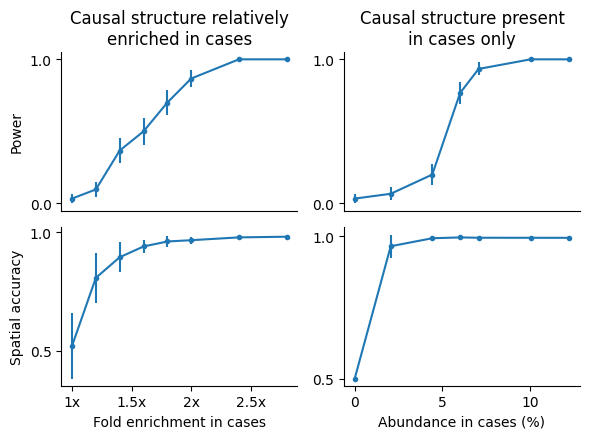

In [3]:
info = pd.read_csv('relative_abundance_performance.csv')
info_caseonly = pd.read_csv('caseonly_abundance_performance.csv').fillna(0)
info_caseonly.loc[0, ['auroc', 'auroc_std']] = 0.5, 0

f, axs = plt.subplots(2, 2, figsize=(6,4.5))
axs[0,0].errorbar(info.ratio, info.power,
                                 marker='.',
                                 yerr=info.power_std/np.sqrt(info.n))
axs[0,0].set_ylabel('Power', fontsize=fs_axislabel)
axs[0,0].set_yticks([0,1],['0.0','1.0'])
axs[0,0].set_xticks([])
axs[0,0].spines[['top','right']].set_visible(False)

axs[1,0].errorbar(info.ratio, info.auroc,
                                 marker='.',
                                 yerr=info.auroc_std)
axs[1,0].set_ylabel('Spatial accuracy', fontsize=fs_axislabel)
axs[1,0].set_xlabel('Fold enrichment in cases', fontsize=fs_axislabel)
axs[1,0].set_yticks([0.5,1],['0.5','1.0'])
axs[1,0].set_xticks([1, 1.5, 2, 2.5],['1x','1.5x','2x','2.5x'])
axs[1,0].spines[['top','right']].set_visible(False)

axs[0,1].errorbar(info_caseonly.case_mean*100, info_caseonly.power,
                                 marker='.',
                                 yerr=info_caseonly.power_std/np.sqrt(info_caseonly.n))
axs[0,1].set_yticks([0,1],['0.0','1.0'])
axs[0,1].set_xticks([])
axs[0,1].spines[['top','right']].set_visible(False)

axs[1,1].errorbar(info_caseonly.case_mean*100, info_caseonly.auroc,
                                 marker='.',
                                 yerr=info_caseonly.auroc_std)
axs[1,1].set_xlabel('Abundance in cases (%)', fontsize=fs_axislabel)
axs[1,1].set_yticks([0.5,1],['0.5','1.0'])
axs[1,1].spines[['top','right']].set_visible(False)

axs[0,0].set_title('Causal structure relatively\nenriched in cases', fontsize=12)
axs[0,1].set_title('Causal structure present\nin cases only', fontsize=12)
f.tight_layout()
f.savefig('../_supp/fig.powersim.power_accuracy.png', dpi=500)
f.show()